In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Load data

In [2]:
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("fact_sales.csv")

Read data

In [3]:
customers.head()

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date
0,1,11000,AW00011000,Jon,Yang,Australia,Married,Male,1971-10-06,2025-10-06
1,2,11001,AW00011001,Eugene,Huang,Australia,Single,Male,1976-05-10,2025-10-06
2,3,11002,AW00011002,Ruben,Torres,Australia,Married,Male,1971-02-09,2025-10-06
3,4,11003,AW00011003,Christy,Zhu,Australia,Single,Female,1973-08-14,2025-10-06
4,5,11004,AW00011004,Elizabeth,Johnson,Australia,Single,Female,1979-08-05,2025-10-06


In [4]:
products.head()

,product_key,product_id,product_number,product_name,category_id,category,subcategory,maintenance,cost,product_line,start_date
0,1,210,FR-R92B-58,HL Road Frame - Black- 58,CO_RF,Components,Road Frames,Yes,0,Road,2003-07-01
1,2,211,FR-R92R-58,HL Road Frame - Red- 58,CO_RF,Components,Road Frames,Yes,0,Road,2003-07-01
2,3,348,BK-M82B-38,Mountain-100 Black- 38,BI_MB,Bikes,Mountain Bikes,Yes,1898,Mountain,2011-07-01
3,4,349,BK-M82B-42,Mountain-100 Black- 42,BI_MB,Bikes,Mountain Bikes,Yes,1898,Mountain,2011-07-01
4,5,350,BK-M82B-44,Mountain-100 Black- 44,BI_MB,Bikes,Mountain Bikes,Yes,1898,Mountain,2011-07-01


In [5]:
sales.head()

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9


Merge datasets

In [8]:
df = sales.merge(customers,on="customer_key",how="left").merge(products,on="product_key",how="left")

In [9]:
df

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price,customer_id,...,product_id,product_number,product_name,category_id,category,subcategory,maintenance,cost,product_line,start_date
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25,16399,...,535,TI-M267,LL Mountain Tire,AC_TT,Accessories,Tires and Tubes,Yes,9,Mountain,2013-07-01
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5,16399,...,528,TT-M928,Mountain Tire Tube,AC_TT,Accessories,Tires and Tubes,Yes,2,Mountain,2013-07-01
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2,16399,...,480,PK-7098,Patch Kit/8 Patches,AC_TT,Accessories,Tires and Tubes,Yes,1,Other Sales,2013-07-01
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22,20280,...,485,FE-6654,Fender Set - Mountain,AC_FE,Accessories,Fenders,No,8,Mountain,2013-07-01
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9,20280,...,481,SO-R809-M,Racing Socks- M,CL_SO,Clothing,Socks,No,3,Road,2013-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO54494,259,11279,2013-03-16,2013-03-23,2013-03-28,2,1,2,22278,...,480,PK-7098,Patch Kit/8 Patches,AC_TT,Accessories,Tires and Tubes,Yes,1,Other Sales,2013-07-01
60394,SO54495,289,3750,2013-03-16,2013-03-23,2013-03-28,5,1,5,14749,...,528,TT-M928,Mountain Tire Tube,AC_TT,Accessories,Tires and Tubes,Yes,2,Mountain,2013-07-01
60395,SO54495,244,3750,2013-03-16,2013-03-23,2013-03-28,35,1,35,14749,...,217,HL-U509,Sport-100 Helmet- Black,AC_HE,Accessories,Helmets,Yes,13,Other Sales,2013-07-01
60396,SO54495,248,3750,2013-03-16,2013-03-23,2013-03-28,50,1,50,14749,...,234,LJ-0192-L,Long-Sleeve Logo Jersey- L,CL_JE,Clothing,Jerseys,No,38,Other Sales,2013-07-01


In [41]:
df.shape

(60398, 33)

In [12]:
df.describe()

,product_key,customer_key,sales_amount,quantity,price,customer_id,product_id,cost
count,60398.000000,60398.000000,60398.000000,60398.000000,60398.000000,60398.000000,60398.000000,60398.000000
mean,212.284331,7842.685420,486.046723,1.000414,486.037783,18841.685420,437.598480,292.563495
std,80.073598,5432.430404,928.450537,0.044011,928.454329,5432.430404,118.063313,563.249698
min,3.000000,1.000000,2.000000,1.000000,2.000000,11000.000000,214.000000,1.000000
25%,138.000000,3004.000000,8.000000,1.000000,8.000000,14003.000000,359.000000,3.000000
50%,246.000000,7144.000000,30.000000,1.000000,30.000000,18143.000000,479.000000,11.000000
75%,285.000000,12430.750000,540.000000,1.000000,540.000000,23429.750000,529.000000,295.000000
max,295.000000,18484.000000,3578.000000,10.000000,3578.000000,29483.000000,606.000000,2171.000000


In [40]:
df.dtypes

order_number                  str
product_key                 int64
customer_key                int64
order_date         datetime64[us]
shipping_date      datetime64[us]
due_date           datetime64[us]
sales_amount                int64
quantity                    int64
price                       int64
customer_id                 int64
customer_number               str
first_name                    str
last_name                     str
country                       str
marital_status                str
gender                        str
birthdate          datetime64[us]
create_date        datetime64[us]
product_id                  int64
product_number                str
product_name                  str
category_id                   str
category                      str
subcategory                   str
maintenance                   str
cost                        int64
product_line                  str
start_date                    str
year                      float64
month         

Convertt Dates

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['shipping_date'] = pd.to_datetime(df['shipping_date'])
df['due_date'] = pd.to_datetime(df['due_date'])
df['create_date'] = pd.to_datetime(df['create_date'])
df['birthdate'] = pd.to_datetime(df['birthdate'])

In [19]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

Profit calculation

In [32]:
df['profit'] = (df['sales_amount'] - df['cost']*df["quantity"])

Age calculation

In [35]:
df['age'] = (pd.Timestamp.now()-df['birthdate']).dt.days//365

Profit margin

In [38]:
df['profit_margin'] = np.where(df['sales_amount']!=0,df['profit']/df['sales_amount'],0)

Key Metrics

In [42]:
total_revenue = np.sum(df['sales_amount'])
total_profit = np.sum(df['profit'])
avg_order_value = np.mean(df['sales_amount'])


print("Revenue: ", total_revenue)
print("Profit: ",total_profit)
print("Avg Order Value: ",avg_order_value)

Revenue:  29356250
Profit:  11685757
Avg Order Value:  486.04672340143713


Sales Trend Over Time

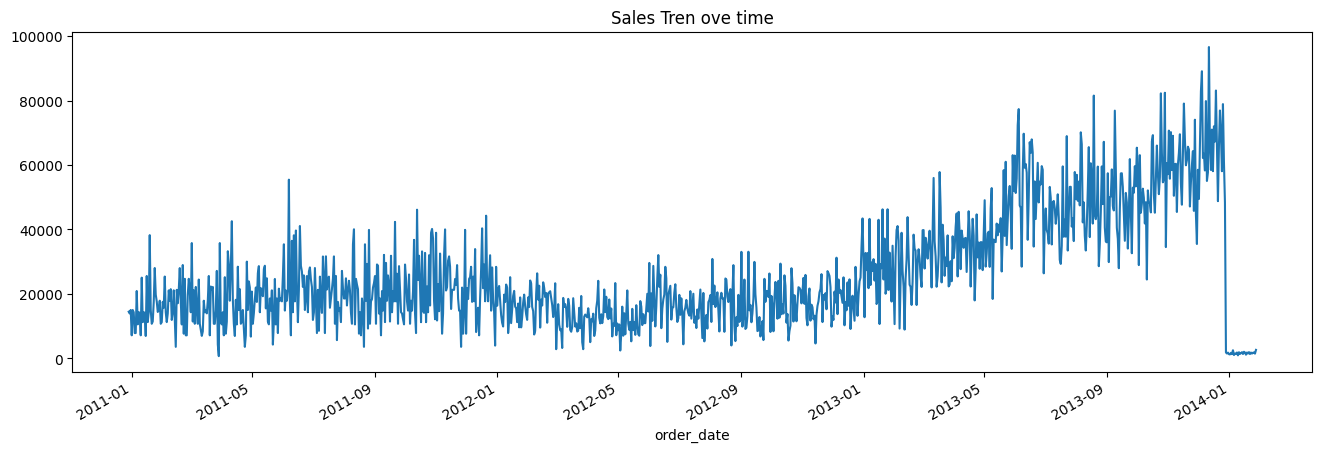

In [44]:
sales_trend = df.groupby('order_date')['sales_amount'].sum()

plt.figure(figsize=(16,5))
sales_trend.plot()
plt.title("Sales Tren ove time")
plt.show()

Month Sales Trend

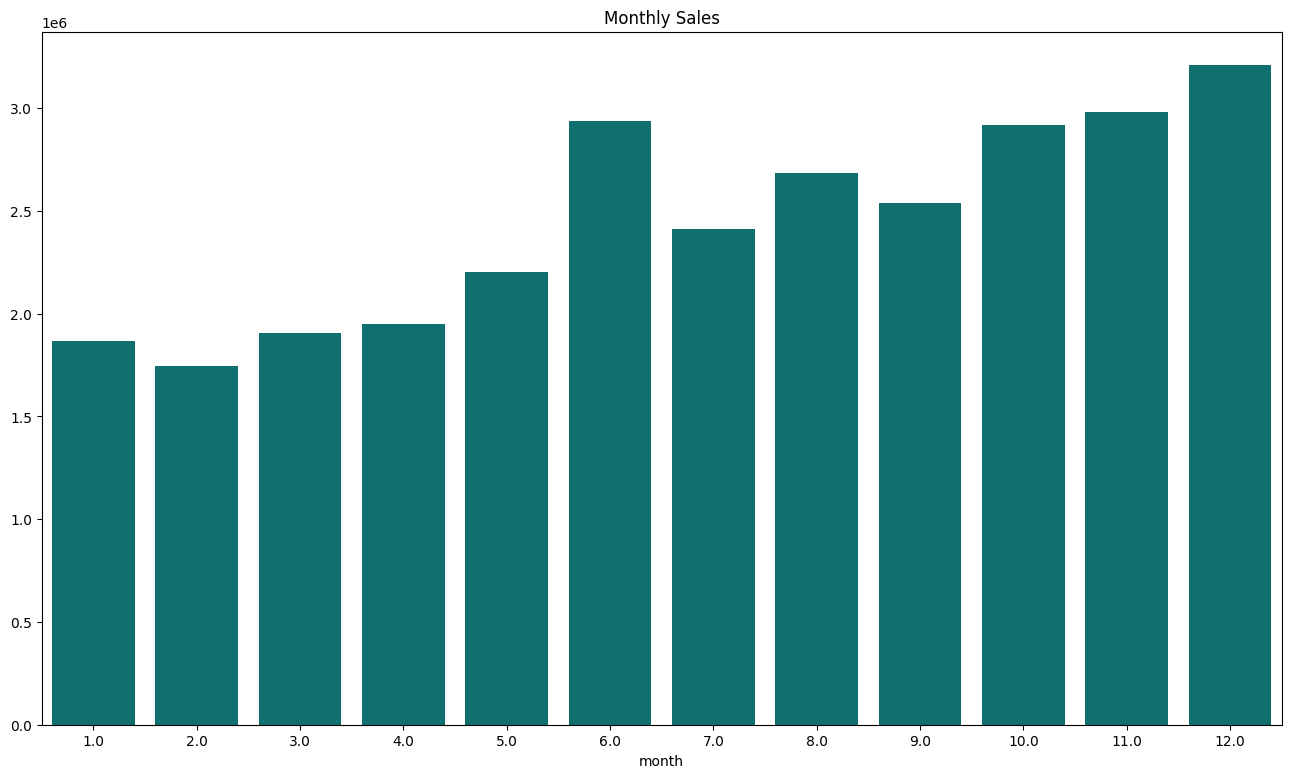

In [50]:
monthly_sales = df.groupby(['month'])['sales_amount'].sum()
plt.figure(figsize=(16,9))
sns.barplot(x=monthly_sales.index,y=monthly_sales.values,color='teal')
plt.title("Monthly Sales")
plt.show()

Revenue By Product Category

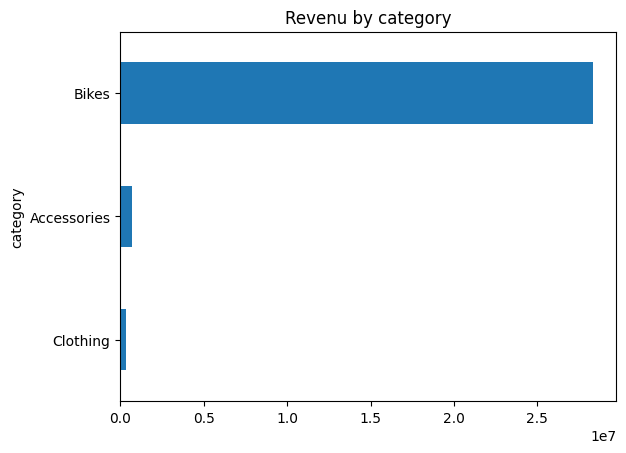

In [52]:
category_sales = df.groupby('category')['sales_amount'].sum().sort_values()
category_sales.plot(kind='barh')
plt.title("Revenu by category")
plt.show()

Top 10 products

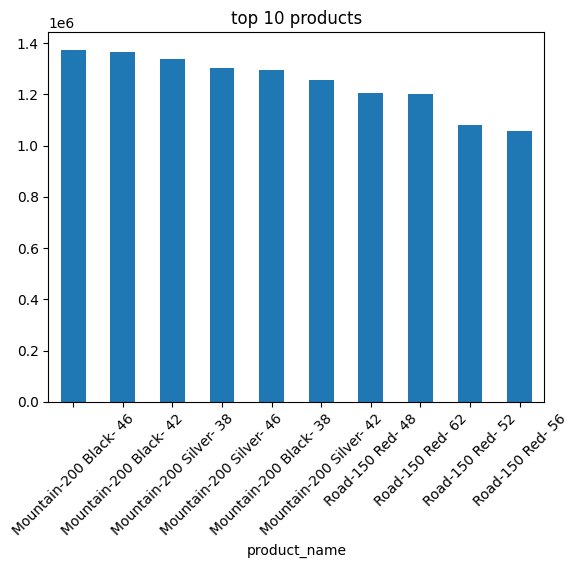

In [59]:
top_products = df.groupby('product_name')['sales_amount'].sum().nlargest(10)
top_products.plot(kind='bar')
plt.title("top 10 products")
plt.xticks(rotation=45)
plt.show()

Profit Distribution

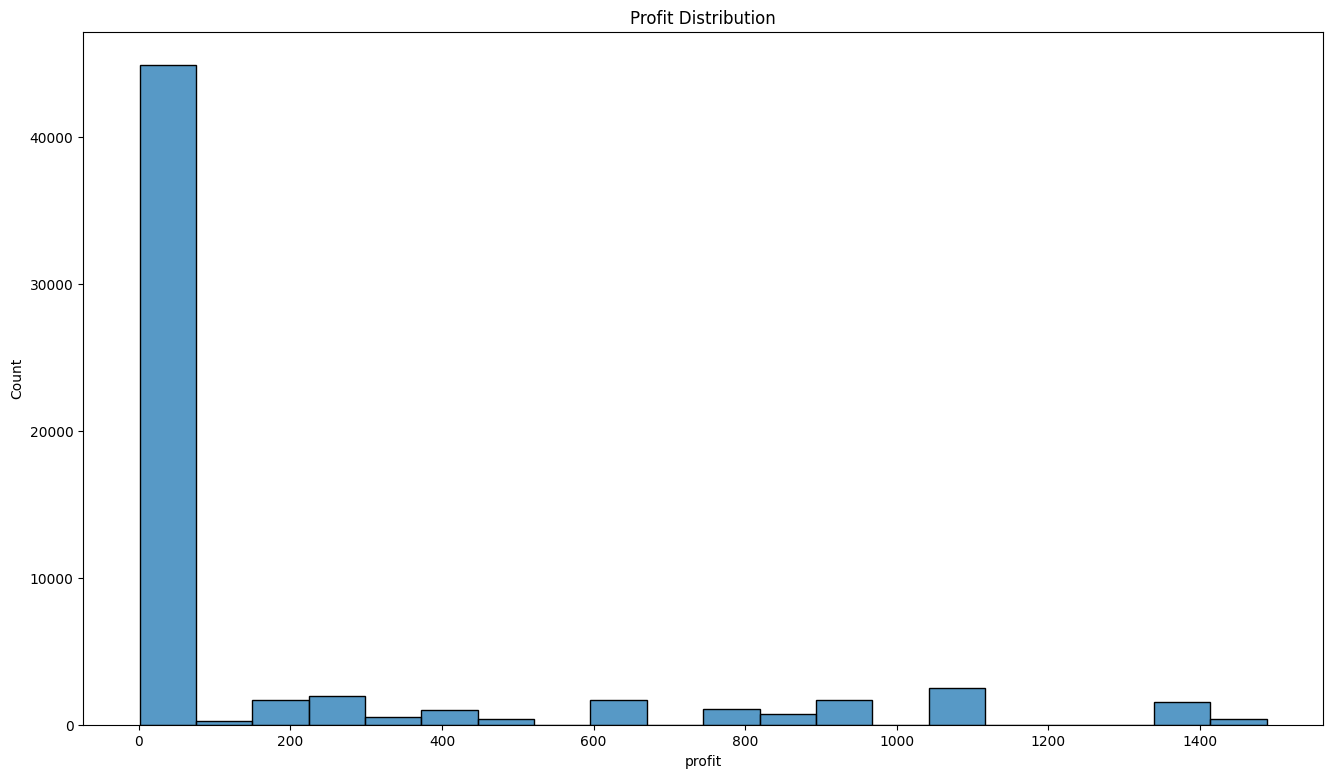

In [64]:
plt.figure(figsize=(16,9))
sns.histplot(df['profit'],bins=20)
plt.title("Profit Distribution")
plt.show()

Sales by gender

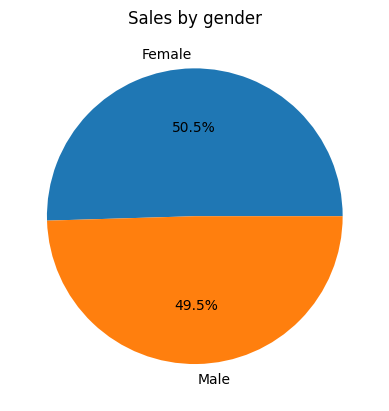

In [65]:
gender_sales = df.groupby('gender')['sales_amount'].sum()
gender_sales.plot(kind='pie',autopct='%1.1f%%')
plt.title("Sales by gender")
plt.show()

Age Vs Spending

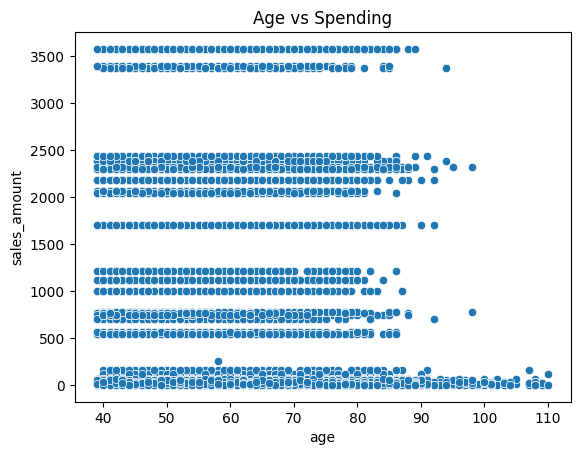

In [66]:
sns.scatterplot(x=df['age'],y=df['sales_amount'])
plt.title("Age vs Spending")
plt.show()

Product Line Performance

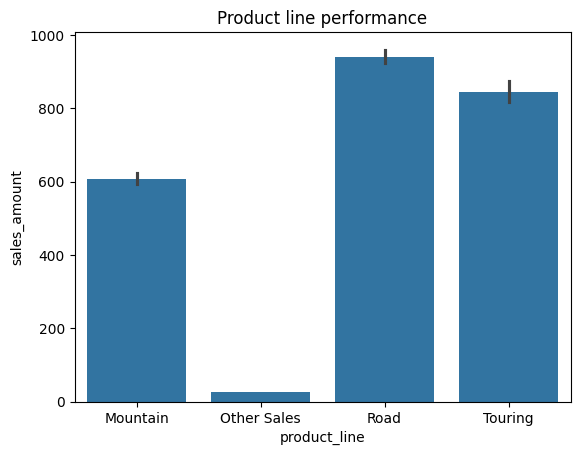

In [67]:
sns.barplot(data=df,x='product_line',y='sales_amount')
plt.title("Product line performance")
plt.show()

Correlation Heatmap

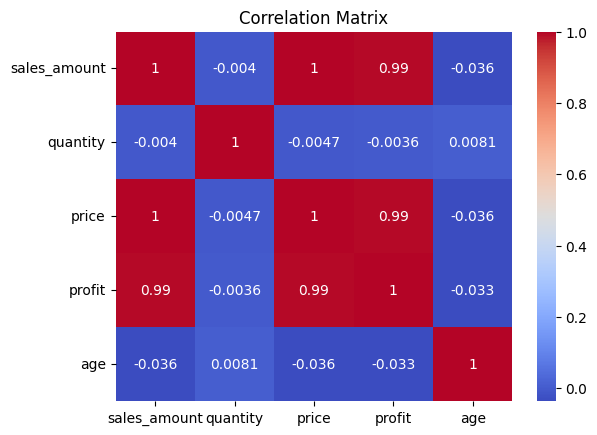

In [69]:
corr = df[['sales_amount','quantity','price','profit','age']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Customer Life Time value(CLV)

In [71]:
clv = df.groupby('customer_id')['sales_amount'].sum().sort_values(ascending=False)
print(clv.head(20))

customer_id
12132    13294
12301    13294
12308    13268
12131    13265
12300    13242
12321    13215
12124    13195
12307    13172
12296    13164
11433    12914
11439    12488
11241    11468
11417    11248
11420    11200
11242    11067
12655    10899
13263    10871
12323    10836
12333    10829
12650    10813
Name: sales_amount, dtype: int64


In [74]:
rfm = df.groupby('customer_id').agg({
    'order_date':lambda x:(df['order_date'].max()-x.max()).days,
    'order_number':'count',
    'sales_amount':'sum'
})

rfm.columns=['Recency','Frequency','Monetary']
print(rfm.head(10))

             Recency  Frequency  Monetary
customer_id                              
11000          270.0          8      8249
11001           49.0         11      6384
11002          339.0          4      8114
11003          263.0          9      8139
11004          272.0          6      8196
11005          271.0          6      8121
11006          259.0          5      8119
11007          315.0          8      8211
11008          332.0          7      8106
11009          264.0          5      8091
